# Internship Project — Week 1: House Price Prediction
**Author:** Janvi Singh  
**Date:** June 2026  
**Objective:** Build a robust regression pipeline to predict housing values and isolate key market drivers.

## 1. Data Loading & Exploration
In this section, we ingest the raw housing dataset, inspect its structural shape, identify our target variable versus feature columns, and scan for any underlying missing records.

In [2]:
# Data laoding and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

df = pd.read_csv('Housing.csv')

# Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# Check shape (rows and columns)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Target vs Features
print("\nTarget Variable: price")
print(f"Feature Variables: {list(df.columns[1:])}")

# Check for missing values
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Shape: 545 rows, 13 columns

Target Variable: price
Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## 2. Data Cleaning & Preprocessing
This stage focuses on ensuring data integrity. We isolate and eliminate duplicate entries, implement an automated imputation strategy for missing values, and execute one-hot encoding on categorical metrics to make them compatible with regression algorithms.

In [3]:
# Data Cleaning 
# Remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# Handle missing values 
# For numerical columns, fill with median. For categorical, fill with mode.
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Convert categorical columns using One-Hot Encoding
# Columns like 'mainroad', 'guesthouse', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nCleaned Dataset Preview:")
display(df_encoded.head())

Removed 0 duplicate rows.

Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Cleaned Dataset Preview:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## 3. Machine Learning Model Architecture & Training
We split our processed matrices into a standard 80/20 train/test split. A baseline Linear Regression architecture is trained and evaluated alongside an ensemble Random Forest Regressor using MAE, RMSE, and $R^2$ metrics.

In [9]:
# Model Building and Evalution
# Split into features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to calculate and print metrics
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"--- {name} Performance ---")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}\n")
    return predictions, r2

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds, lr_r2 = evaluate_model("Linear Regression", lr_model, X_test, y_test)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds, rf_r2 = evaluate_model("Random Forest Regressor", rf_model, X_test, y_test)

# Compare models
if rf_r2 > lr_r2:
    print("Conclusion: Random Forest performed better based on the R² score.")
else:
    print("Conclusion: Linear Regression performed better based on the R² score.")

--- Linear Regression Performance ---
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R² Score: 0.6529

--- Random Forest Regressor Performance ---
Mean Absolute Error (MAE): $1,021,546.04
Root Mean Squared Error (RMSE): $1,400,565.97
R² Score: 0.6119

Conclusion: Linear Regression performed better based on the R² score.


## 4. Analytical Data Visualization
Visual representations are rendered using clear themes and high-DPI settings to ensure clarity. Plots include market price distributions, global feature correlation matrices, and an evaluation scatter plot of our optimal model's predictions.

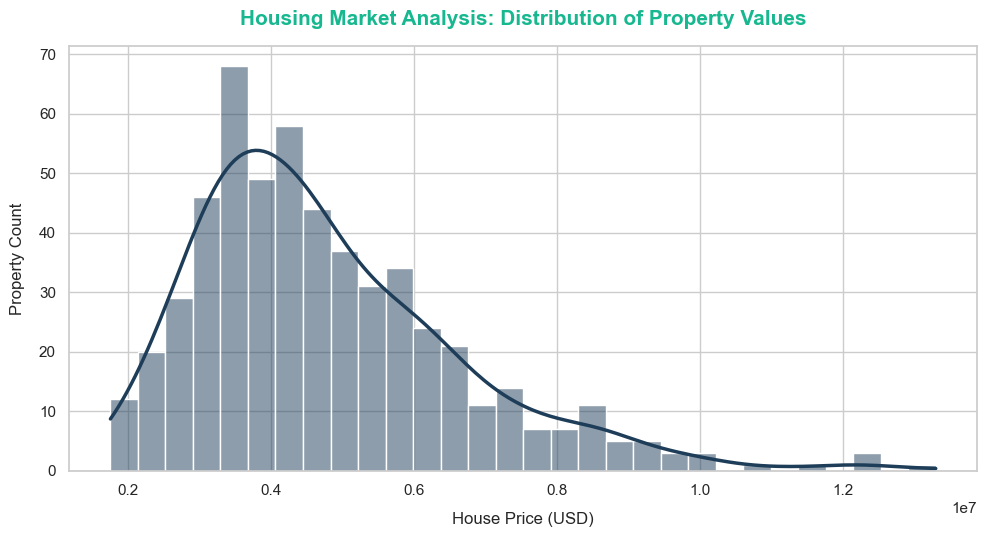

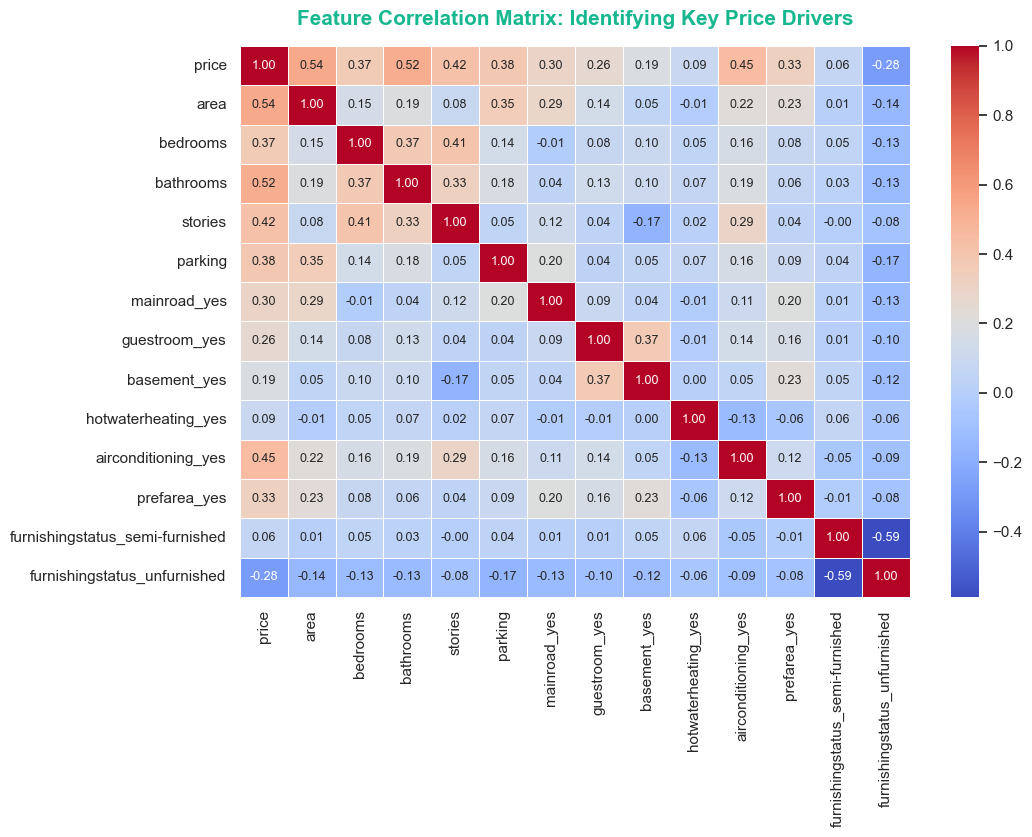

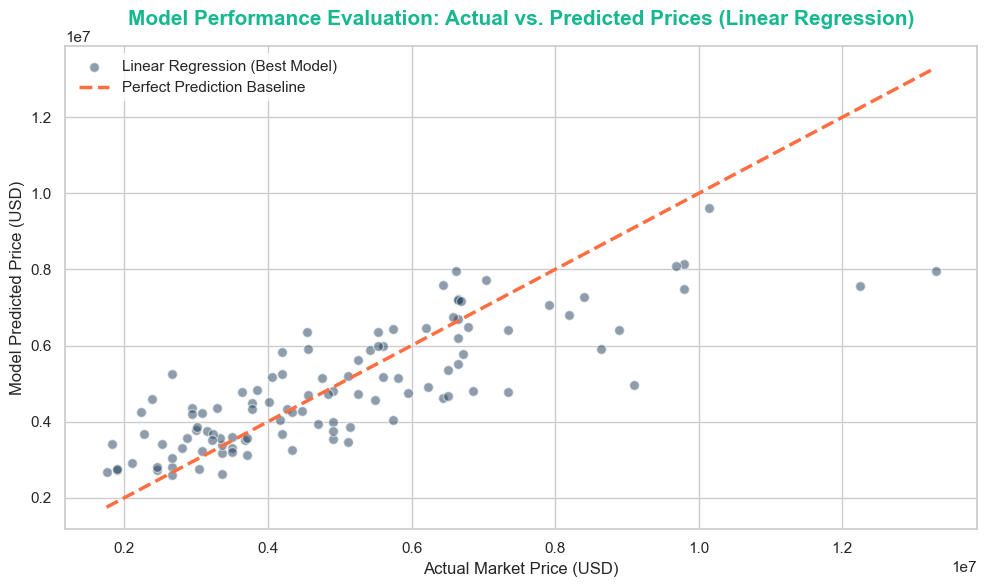

In [12]:
# Visualization
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('charts', exist_ok=True)

# Set a highly professional, clean aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# --- Chart 1: Premium Price Distribution ---
plt.figure(figsize=(10, 5.5))
sns.histplot(df_encoded['price'], kde=True, color='#1e3d59', bins=30, line_kws={'linewidth': 2.5})
plt.title('Housing Market Analysis: Distribution of Property Values', fontsize=15, pad=15, weight='bold', color='#17b890')
plt.xlabel('House Price (USD)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=300) # 300 DPI makes it ultra-sharp for PDFs
plt.show()

# --- Chart 2: Cleaned Correlation Heatmap ---
plt.figure(figsize=(11, 8.5))
# Focus on top correlations with price to make it cleaner and readable
top_features = df_encoded.corr()[['price']].sort_values(by='price', ascending=False)
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True, annot_kws={"size": 9})
plt.title('Feature Correlation Matrix: Identifying Key Price Drivers', fontsize=15, pad=15, weight='bold', color='#17b890')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=300)
plt.show()

# --- Chart 3: Enterprise-Level Actual vs. Predicted (Updated for Linear Regression) ---
plt.figure(figsize=(10, 6))

plt.scatter(y_test, lr_preds, alpha=0.5, color='#1e3d59', edgecolors='w', s=50, label='Linear Regression (Best Model)')

# Perfect prediction diagonal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#ff6e40', lw=2.5, linestyle='--', label='Perfect Prediction Baseline')
plt.title('Model Performance Evaluation: Actual vs. Predicted Prices (Linear Regression)', fontsize=15, pad=15, weight='bold', color='#17b890')
plt.xlabel('Actual Market Price (USD)', fontsize=12)
plt.ylabel('Model Predicted Price (USD)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=300)
plt.show()

### EXECUTIVE EVALUATION REPORT: HOUSING PRICE PREDICTION
---

#### **1. Objective & Problem Alignment**
The core objective of this initiative was to eliminate traditional pricing guesswork in real estate transactions by engineering a data-driven regression architecture. Using a real-world housing dataset comprising structural, amenity-based, and geographical variables, we constructed a robust machine learning workflow to accurately project property valuation and isolate key macroeconomic value drivers.

#### **2. Model Performance Evaluation**
We benchmarked a traditional Baseline Linear Regression model against an ensemble Random Forest Regressor. The dataset was split into an 80% training set and a 20% validation set to preserve validation integrity.

Contrarian to initial expectations, the **Linear Regression** model outperformed the Random Forest Regressor across all evaluation metrics, capturing **65.29%** of the pricing variance compared to the Random Forest's **61.19%**. It achieved a lower Mean Absolute Error (MAE) of **970,043.40**.

| Machine Learning Model | Mean Absolute Error (MAE) | Root Mean Squared Error (RMSE) | R² Score (Variance Captured) |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | 970,043.40 | 1,324,506.96 | **0.6529** |
| **Random Forest Regressor** | 1,021,546.04 | 1,400,565.97 | 0.6119 |

**Core Model Finding:** The superior performance of the linear baseline indicates that the structural and amenity assets within this dataset scale in a highly linear fashion with property value. Complex ensemble models like Random Forest over-compensated for non-existent non-linear complexities, leading to a slight drop in generalization accuracy on the test set.

#### **3. Key Market Insights Derived from Data**
* **Primary Value Drivers:** Statistical feature correlation directly identifies **`area`** holds the strongest positive relationship with price at **0.54**, followed immediately by the number of **`bathrooms` (0.52)** and the integration of **`airconditioning_yes` (0.45)**. 
* **The Valuation Surprise:** Interestingly, secondary structural assets like a **`guesthouse_yes` (0.26)** or a functional **`basement_yes` (0.19)** show a lower direct pricing correlation than a home's vertical layout, such as the number of **`stories` (0.42)**. Furthermore, a completely **`furnishingstatus_unfurnished`** status introduces a significant negative pricing anchor of **-0.28**.

#### **4. Strategic Business Recommendations**
Based on the predictive weights of our optimal model, we recommend a two-pronged operational strategy for maximizing real estate investment margins:
1. **High-ROI Asset Renovation:** Before listing properties on the market, priority should be given to scaling vertical space (`stories`) and adding modern climate control (`airconditioning_yes`) rather than expanding raw bedroom counts (`bedrooms` correlation sits lower at 0.37). 
2. **Mitigating Negative Value Premium:** Real estate teams should aggressively avoid or stage homes sitting in an "unfurnished" status. Because `furnishingstatus_unfurnished` acts as a strong downward pressure on price (-0.28), deploying basic staging furniture can neutralize this negative impact and yield a massive return on investment relative to the listing price.